# XGBoost Hyperparameter Tuning

Two-phase tuning using anchored-expanding cross-validation:

1. **Phase 1 (Random search)**: Broad random search across ~50 configs on a random subset of folds to understand the hyperparameter landscape and narrow ranges
2. **Phase 2 (Bayesian search)**: Optuna Bayesian optimization over the narrowed search space evaluated on ALL folds

CV structure: train always anchored at earliest date, 12-month validation window,
12-month holdout window, 1-month embargo, ~15 folds.

In [2]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from scipy.stats import spearmanr
import time
import optuna
from joblib import Parallel, delayed
import multiprocessing
import xgboost as xgb


from src.features.gkx_registry import GKX_94
from src.ensemble import anchored_expanding_cv, XGBRanker

c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# -- Load data (monthly modeling panel) --
run_tag = "run_5000_nonetf_1990"
gkx_path = f"../data/processed/{run_tag}/gkx_monthly.parquet"
daily_path = f"../data/processed/{run_tag}/final_dataset.parquet"

gkx = pd.read_parquet(gkx_path)
daily = pd.read_parquet(daily_path)

# Fix _x/_y suffixes from prior merges
daily = daily.drop(columns=[c for c in daily.columns if c.endswith("_x")], errors="ignore")
daily.columns = [c.replace("_y", "") for c in daily.columns]

daily["date"] = pd.to_datetime(daily["date"])
daily["month_end"] = daily["date"] + pd.offsets.MonthEnd(0)

# Month-end close per ticker
px_m = (
    daily.sort_values(["ticker", "date"])
    .groupby(["ticker", "month_end"], as_index=False)
    .tail(1)[["ticker", "month_end", "close"]]
)
px_m = px_m.sort_values(["ticker", "month_end"])
px_m["ret_eom_t+1"] = px_m.groupby("ticker")["close"].shift(-1) / px_m["close"] - 1

# SPY benchmark return
df_spy = px_m.loc[px_m["ticker"] == "SPY", ["month_end", "ret_eom_t+1"]].rename(
    columns={"ret_eom_t+1": "spy_ret_eom_t+1"}
)

# Macro features
macro_cols = [
    "DFF",
    "DGS10",
    "DGS2",
    "T10Y2Y",
    "CPIAUCSL",
    "CPILFESL",
    "PCEPI",
    "GDP",
    "GDPC1",
    "INDPRO",
    "UNRATE",
    "PAYEMS",
    "ICSA",
    "UMCSENT",
    "RSXFS",
    "VIXCLS",
    "DCOILWTICO",
    "M2SL",
    "TOTALSL",
]
macro_m = (
    daily.sort_values("date")
    .groupby("month_end", as_index=False)
    .tail(1)[["month_end"] + macro_cols]
    .drop_duplicates("month_end")
)

# Build modeling table
df = gkx.merge(
    px_m[["ticker", "month_end", "ret_eom_t+1"]],
    on=["ticker", "month_end"],
    how="left",
)
df = df.merge(df_spy, on="month_end", how="left")
df = df.merge(macro_m, on="month_end", how="left")

# Winsorize monthly cross-section of next-month returns
lo = df.groupby("month_end")["ret_eom_t+1"].transform(lambda x: x.quantile(0.01))
hi = df.groupby("month_end")["ret_eom_t+1"].transform(lambda x: x.quantile(0.99))
df["ret_eom_t+1"] = df["ret_eom_t+1"].clip(lower=lo, upper=hi)

# Features used for modeling
all_gkx_cols = [c for c in GKX_94 if c in df.columns]
feature_cols = all_gkx_cols + [c for c in macro_cols if c in df.columns]

# Filter to rows with valid target
model_df = df[["ticker", "month_end", "ret_eom_t+1"] + feature_cols].copy()
model_df = model_df[model_df["ret_eom_t+1"].notna()].reset_index(drop=True)
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# Integrity checks
dup_keys = model_df.duplicated(["ticker", "month_end"]).sum()
monthly_n = model_df.groupby("month_end")["ticker"].nunique()
missing_by_feature = model_df[feature_cols].isna().mean().sort_values(ascending=False)
top_missing_features = missing_by_feature.head(20).rename("missing_ratio").to_frame()

model_df_checks = pd.DataFrame(
    {
        "metric": [
            "rows",
            "tickers",
            "months",
            "duplicate_(ticker,month_end)",
            "min_names_per_month",
            "median_names_per_month",
            "max_names_per_month",
        ],
        "value": [
            len(model_df),
            model_df["ticker"].nunique(),
            model_df["month_end"].nunique(),
            int(dup_keys),
            int(monthly_n.min()),
            float(monthly_n.median()),
            int(monthly_n.max()),
        ],
    }
)

print(model_df_checks.to_string(index=False))
print(f"Date range: {model_df['month_end'].min()} to {model_df['month_end'].max()}")
print(f"Total features: {len(feature_cols)}")
print("\nTop 10 most-missing features:")
print(top_missing_features.head(10).to_string())


                      metric    value
                        rows 997314.0
                     tickers   5002.0
                      months    433.0
duplicate_(ticker,month_end)      0.0
         min_names_per_month    723.0
      median_names_per_month   2144.0
         max_names_per_month   5002.0
Date range: 1990-01-31 00:00:00 to 2026-01-31 00:00:00
Total features: 113

Top 10 most-missing features:
            missing_ratio
chcsho           1.000000
ms               1.000000
chempia          0.442515
hire             0.429518
secured          0.410699
lgr              0.368317
realestate       0.368140
invest           0.365944
agr              0.365944
grltnoa          0.365944


In [4]:
raw_gkx_cols = [c for c in GKX_94 if c in model_df.columns]
macro_feature_cols = [c for c in macro_cols if c in model_df.columns]

predictor_cols = (
    raw_gkx_cols
    + [f"{col}_csrank" for col in raw_gkx_cols]
    + [f"{col}_csnorm" for col in raw_gkx_cols]
    + macro_feature_cols
)

print(f"Raw GKX cols available: {len(raw_gkx_cols)}")
print(f"Macro cols available:   {len(macro_feature_cols)}")
print(f"Total predictor cols:   {len(predictor_cols)}")


Raw GKX cols available: 94
Macro cols available:   19
Total predictor cols:   301


# Fold setup is defined in the next cell.
# (This cell intentionally left as a lightweight placeholder.)


In [5]:
# Generate anchored-expanding CV folds.
# step_months is set to 72 to avoid cross-fold overlap between
# validation and holdout windows when val_months=36 and holdout_months=36.
cv_kwargs = dict(
    min_train_months=144,
    val_months=36,
    holdout_months=36,
    step_months=72,
    embargo_months=1,
)

folds = list(anchored_expanding_cv(model_df, date_col="month_end", **cv_kwargs))
print(f"Total folds: {len(folds)}\n")

unique_months = pd.Index(np.sort(model_df["month_end"].unique()))


def month_count(start, end):
    mask = (unique_months >= start) & (unique_months <= end)
    return int(mask.sum())


# Integrity checks: strict ordering + no within-fold overlap
cv_rows = []
for f in folds:
    train_mask = f["train_mask"]
    val_mask = f["val_mask"]
    holdout_mask = f["holdout_mask"]

    idx_train = np.flatnonzero(train_mask)
    idx_val = np.flatnonzero(val_mask)
    idx_holdout = np.flatnonzero(holdout_mask)

    train_val_overlap = int(np.intersect1d(idx_train, idx_val).size)
    train_holdout_overlap = int(np.intersect1d(idx_train, idx_holdout).size)
    val_holdout_overlap = int(np.intersect1d(idx_val, idx_holdout).size)

    strict_time_order = bool(
        f["train_end"] < f["val_start"] <= f["val_end"] < f["holdout_start"] <= f["holdout_end"]
    )

    cv_rows.append(
        {
            "fold": f["fold"],
            "train_end": f["train_end"].strftime("%Y-%m"),
            "val": f"{f['val_start'].strftime('%Y-%m')} -> {f['val_end'].strftime('%Y-%m')}",
            "holdout": f"{f['holdout_start'].strftime('%Y-%m')} -> {f['holdout_end'].strftime('%Y-%m')}",
            "train_months": month_count(unique_months.min(), f["train_end"]),
            "val_months": month_count(f["val_start"], f["val_end"]),
            "holdout_months": month_count(f["holdout_start"], f["holdout_end"]),
            "n_train_rows": int(train_mask.sum()),
            "n_val_rows": int(val_mask.sum()),
            "n_holdout_rows": int(holdout_mask.sum()),
            "train_val_overlap_rows": train_val_overlap,
            "train_holdout_overlap_rows": train_holdout_overlap,
            "val_holdout_overlap_rows": val_holdout_overlap,
            "strict_time_order": strict_time_order,
        }
    )

fold_df = pd.DataFrame(cv_rows)
print(fold_df.to_string(index=False))

if (
    fold_df[["train_val_overlap_rows", "train_holdout_overlap_rows", "val_holdout_overlap_rows"]]
    > 0
).any().any():
    raise ValueError("Fold leakage detected: overlap rows found within a fold")
if not fold_df["strict_time_order"].all():
    raise ValueError("Fold integrity failed: non-chronological split found")


Total folds: 4

 fold train_end                val            holdout  train_months  val_months  holdout_months  n_train_rows  n_val_rows  n_holdout_rows  train_val_overlap_rows  train_holdout_overlap_rows  val_holdout_overlap_rows  strict_time_order
    0   2001-12 2002-02 -> 2005-01 2005-02 -> 2008-01           144          36              36        165438       62090           71920                       0                           0                         0               True
    1   2007-12 2008-02 -> 2011-01 2011-02 -> 2014-01           216          36              36        298914       80014           88953                       0                           0                         0               True
    2   2013-12 2014-02 -> 2017-01 2017-02 -> 2020-01           288          36              36        467393      102116          116629                       0                           0                         0               True
    3   2019-12 2020-02 -> 2023-01 2023-02 -

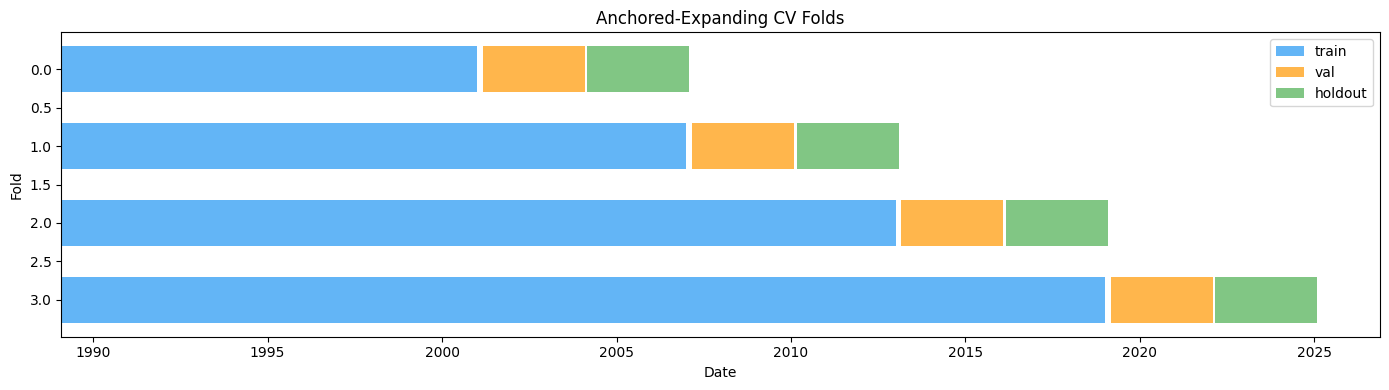

In [6]:
# Gantt chart of CV folds
fig, ax = plt.subplots(figsize=(14, max(4, len(folds) * 0.4)))

colors = {"train": "#2196F3", "val": "#FF9800", "holdout": "#4CAF50"}
dates_sorted = np.sort(model_df["month_end"].unique())
date_min, date_max = dates_sorted[0], dates_sorted[-1]

for f in folds:
    y = f["fold"]
    ax.barh(y, (f["train_end"] - date_min).days, left=0,
            height=0.6, color=colors["train"], alpha=0.7)
    ax.barh(y, (f["val_end"] - f["val_start"]).days,
            left=(f["val_start"] - date_min).days,
            height=0.6, color=colors["val"], alpha=0.7)
    ax.barh(y, (f["holdout_end"] - f["holdout_start"]).days,
            left=(f["holdout_start"] - date_min).days,
            height=0.6, color=colors["holdout"], alpha=0.7)

year_ticks = pd.date_range(date_min, date_max, freq="5YE")
ax.set_xticks([(t - date_min).days for t in year_ticks])
ax.set_xticklabels([t.strftime("%Y") for t in year_ticks])

ax.set_ylabel("Fold")
ax.set_xlabel("Date")
ax.set_title("Anchored-Expanding CV Folds")
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.7, label=l) for l, c in colors.items()]
ax.legend(handles=legend_elements, loc="upper right")
plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import spearmanr


def cross_sectional_ic(df, date_col, return_col, pred_col):
    """Average within-month Spearman IC on raw returns."""
    ic_list = []
    for _, group in df.groupby(date_col):
        y = group[return_col].to_numpy()
        p = group[pred_col].to_numpy()
        mask = np.isfinite(y) & np.isfinite(p)
        if mask.sum() < 10:
            continue
        corr, _ = spearmanr(y[mask], p[mask])
        if np.isfinite(corr):
            ic_list.append(corr)
    return float(np.mean(ic_list)) if ic_list else 0.0


def compute_monthly_spreads(
    df, date_col, return_col, pred_col, top_frac=0.10, bottom_frac=0.10
):
    """Top-minus-bottom spread using raw returns within each month."""
    spreads = []
    for _, group in df.groupby(date_col):
        group = group.sort_values(pred_col)
        n = len(group)
        n_top = int(np.floor(n * top_frac))
        n_bot = int(np.floor(n * bottom_frac))
        if n_top < 1 or n_bot < 1:
            continue
        bottom = group.iloc[:n_bot][return_col].mean()
        top = group.iloc[-n_top:][return_col].mean()
        spreads.append(top - bottom)
    return np.asarray(spreads, dtype=np.float64)


def sharpe_ratio(returns, annualization=12):
    returns = np.asarray(returns, dtype=np.float64)
    if returns.size < 3:
        return 0.0
    mean = returns.mean()
    std = returns.std(ddof=0)
    if not np.isfinite(std) or std == 0:
        return 0.0
    return float((mean / std) * np.sqrt(annualization))


def cs_zscore(series: pd.Series) -> pd.Series:
    """Cross-sectional z-score for one month, robust to zero std."""
    values = pd.to_numeric(series, errors="coerce")
    mu = values.mean()
    sigma = values.std(ddof=0)
    if not np.isfinite(sigma) or sigma == 0:
        return pd.Series(np.zeros(len(values), dtype=np.float32), index=series.index)
    z = (values - mu) / sigma
    return z.astype(np.float32)


def compute_cs_features_by_split(
    df,
    split_mask,
    gkx_features,
    macro_features,
    date_col="month_end",
):
    """
    Build split-local features to avoid leakage:
    - c_i,t raw GKX
    - csrank(c_i,t), csnorm(c_i,t) within month and split
    - macro x_t (raw)
    - target z-score (for training objective)
    """
    transformed_suffixes = (
        "_csrank",
        "_csnorm",
        "_zscore",
        "_rank",
        "_quintile",
        "_sector_rel",
        "_sector_rank",
    )

    split_df = df.loc[split_mask].copy()
    drop_cols = [c for c in split_df.columns if c.endswith(transformed_suffixes)]
    if drop_cols:
        split_df = split_df.drop(columns=drop_cols)

    split_df[date_col] = pd.to_datetime(split_df[date_col])

    available_gkx = [c for c in gkx_features if c in split_df.columns]
    available_macro = [c for c in macro_features if c in split_df.columns]

    grouped = split_df.groupby(date_col, sort=False)

    for feat in available_gkx:
        cs_rank = grouped[feat].rank(method="average", pct=True)
        split_df[f"{feat}_csrank"] = cs_rank.astype(np.float32)
        split_df[f"{feat}_csnorm"] = (2.0 * cs_rank - 1.0).astype(np.float32)

    # TODO --- Add in secotor-relative features here ---

    # Compute date-level Z Score for next period returns
    mean = grouped["ret_eom_t+1"].transform("mean")
    std = grouped["ret_eom_t+1"].transform("std")
    split_df["ret_eom_t+1_zscore"] = (split_df["ret_eom_t+1"] - mean) / std

    split_df = split_df.replace([np.inf, -np.inf], np.nan)

    out_features = (
        available_gkx
        + [f"{feat}_csrank" for feat in available_gkx]
        + [f"{feat}_csnorm" for feat in available_gkx]
        + available_macro
    )

    return split_df, out_features


def prepare_fold_data_correct(
    model_df, fold_info, gkx_features, macro_features, date_col="month_end"
):
    """
    Prepare fold data while preserving your constraints:
    - csrank/csnorm computed separately in each split
    - train target is z-scored within split month
    - validation metrics are computed on raw returns
    """
    train_mask = fold_info["train_mask"]
    val_mask = fold_info["val_mask"]

    # Hard guard against overlap within this fold
    if np.intersect1d(np.flatnonzero(train_mask), np.flatnonzero(val_mask)).size > 0:
        raise ValueError(f"Fold {fold_info['fold']} has train/val overlap")

    train_df, train_features = compute_cs_features_by_split(
        model_df, train_mask, gkx_features, macro_features, date_col
    )
    val_df, val_features = compute_cs_features_by_split(
        model_df, val_mask, gkx_features, macro_features, date_col
    )

    common_features = [c for c in train_features if c in val_features]
    if not common_features:
        raise ValueError(f"Fold {fold_info['fold']} has no common train/val features")

    X_train = train_df[common_features].to_numpy(dtype=np.float32)
    y_train = train_df["ret_eom_t+1_zscore"].to_numpy(dtype=np.float32)
    X_val = val_df[common_features].to_numpy(dtype=np.float32)
    y_val = val_df["ret_eom_t+1_zscore"].to_numpy(dtype=np.float32)

    val_df_meta = val_df[["ticker", date_col, "ret_eom_t+1", "ret_eom_t+1_zscore"]].copy()

    fold_diag = {
        "fold": int(fold_info["fold"]),
        "train_rows": int(len(train_df)),
        "val_rows": int(len(val_df)),
        "n_features": int(len(common_features)),
        "train_months": int(train_df[date_col].nunique()),
        "val_months": int(val_df[date_col].nunique()),
    }

    return X_train, y_train, X_val, y_val, val_df_meta, common_features, fold_diag


def evaluate_params_on_folds(params, fold_list, verbose=False):
    """Train XGBoost across folds with split-local CS features and z-score target."""
    fold_mse = []
    fold_spreads = []
    fold_cs_ic = []
    fold_best_iter = []
    fold_feature_counts = []
    fold_row_counts = []

    for fold_info in fold_list:
        X_tr, y_tr, X_va, y_va, val_df_meta, fold_features, fold_diag = (
            prepare_fold_data_correct(
                model_df,
                fold_info,
                raw_gkx_cols,
                macro_feature_cols,
                date_col="month_end",
            )
        )

        dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=fold_features)
        dval = xgb.DMatrix(X_va, label=y_va, feature_names=fold_features)

        full_params = {
            "objective": "reg:pseudohubererror",
            "tree_method": "hist",
            "nthread": 3,
            **params,
        }

        model = xgb.train(
            full_params,
            dtrain,
            num_boost_round=1000,
            evals=[(dval, "valid")],
            early_stopping_rounds=30,
            verbose_eval=False,
        )

        preds = model.predict(dval)
        val_df_meta["pred"] = preds

        fold_mse.append(float(model.best_score))
        fold_best_iter.append(int(model.best_iteration))
        fold_cs_ic.append(cross_sectional_ic(val_df_meta, "month_end", "ret_eom_t+1", "pred"))
        fold_spreads.append(
            compute_monthly_spreads(val_df_meta, "month_end", "ret_eom_t+1", "pred")
        )
        fold_feature_counts.append(fold_diag["n_features"])
        fold_row_counts.append((fold_diag["train_rows"], fold_diag["val_rows"]))

        if verbose:
            print(
                f"Fold {fold_info['fold']}: train={fold_diag['train_rows']}, "
                f"val={fold_diag['val_rows']}, features={fold_diag['n_features']}, "
                f"CS-IC={fold_cs_ic[-1]:.4f}"
            )

    return {
        "fold_mse": fold_mse,
        "fold_spreads": fold_spreads,
        "fold_cs_ic": fold_cs_ic,
        "fold_best_iter": fold_best_iter,
        "fold_feature_counts": fold_feature_counts,
        "fold_row_counts": fold_row_counts,
    }


def score_fold_spreads(fold_spreads):
    """Sharpe per fold, then average."""
    fold_sharpes = [sharpe_ratio(s) for s in fold_spreads if len(s) >= 3]
    return float(np.mean(fold_sharpes)) if fold_sharpes else 0.0


In [9]:
# Quick sanity check of the split-local feature/target pipeline
_fold0 = folds[0]
X_tr0, y_tr0, X_va0, y_va0, va_meta0, feat0, diag0 = prepare_fold_data_correct(
    model_df,
    _fold0,
    raw_gkx_cols,
    macro_feature_cols,
    date_col="month_end",
)

fold0_checks = pd.Series(
    {
        "fold": diag0["fold"],
        "train_rows": diag0["train_rows"],
        "val_rows": diag0["val_rows"],
        "n_features": diag0["n_features"],
        "train_months": diag0["train_months"],
        "val_months": diag0["val_months"],
        "train_target_mean": float(np.nanmean(y_tr0)),
        "train_target_std": float(np.nanstd(y_tr0)),
        "val_raw_ret_mean": float(va_meta0["ret_eom_t+1"].mean()),
        "val_raw_ret_std": float(va_meta0["ret_eom_t+1"].std(ddof=0)),
    }
)
print(fold0_checks.to_string())


C:\Users\amsac\AppData\Local\Temp\ipykernel_80412\2061577868.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csnorm"] = (2.0 * cs_rank - 1.0).astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_80412\2061577868.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csrank"] = cs_rank.astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_80412\2061577868.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

fold                 0.000000e+00
train_rows           1.654380e+05
val_rows             6.209000e+04
n_features           3.010000e+02
train_months         1.440000e+02
val_months           3.600000e+01
train_target_mean   -2.766980e-10
train_target_std     9.995647e-01
val_raw_ret_mean     1.792716e-02
val_raw_ret_std      1.240440e-01


---
## Phase 1: Random Search (Landscape Exploration)

Broad grid, random sample of configs, evaluated on a random subset of folds.
Goal: understand which hyperparameter ranges matter and narrow the space.

In [10]:
# Broad search space
grid_values = dict(
    max_depth=[2, 3, 4, 5],
    learning_rate=[0.005, 0.01, 0.025],
    subsample=[0.35, 0.6, 0.75, 0.9],
    colsample_bytree=[0.4, 0.65, 0.9],
    min_child_weight=[1, 10, 20, 100],
    alpha=[0.1, 1.0, 5.0],
)

param_grid = [
    dict(zip(grid_values.keys(), vals))
    for vals in product(*grid_values.values())
]
print(f"Full grid size: {len(param_grid)}")

# Random sample of configs for Phase 1
N_RANDOM = min(40, len(param_grid))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(param_grid), size=N_RANDOM, replace=False)
sampled_configs = [param_grid[i] for i in sample_idx]

# Random subset of folds for fast screening
N_FOLDS_P1 = min(3, len(folds))
fold_idx = rng.choice(len(folds), size=N_FOLDS_P1, replace=False)
p1_folds = [folds[i] for i in sorted(fold_idx)]
print(f"Phase 1: {N_RANDOM} configs x {N_FOLDS_P1} folds (folds {sorted(fold_idx)})")


Full grid size: 1728
Phase 1: 40 configs x 3 folds (folds [np.int32(0), np.int32(1), np.int32(2)])


### Run Phase 1 using parallel trials

In [ ]:
%%time

N_CORES = multiprocessing.cpu_count()

import os

os.environ["OMP_NUM_THREADS"] = "3"

N_PARALLEL = min(4, max(1, N_CORES // 2))


def evaluate_single_config(params, idx):
    results = evaluate_params_on_folds(params, p1_folds, verbose=False)

    avg_best_iter = float(np.mean(results["fold_best_iter"])) if results["fold_best_iter"] else 0.0
    min_best_iter = int(np.min(results["fold_best_iter"])) if results["fold_best_iter"] else 0
    mean_mse = float(np.mean(results["fold_mse"])) if results["fold_mse"] else np.nan
    std_mse = float(np.std(results["fold_mse"])) if results["fold_mse"] else np.nan
    spread_sharpe = score_fold_spreads(results["fold_spreads"])
    mean_cs_ic = float(np.mean(results["fold_cs_ic"])) if results["fold_cs_ic"] else np.nan

    all_spreads = np.concatenate(results["fold_spreads"]) if results["fold_spreads"] else np.array([])
    result = {
        **params,
        "avg_best_iter": avg_best_iter,
        "min_best_iter": min_best_iter,
        "mean_feature_count": float(np.mean(results["fold_feature_counts"])),
        "cs_ic": mean_cs_ic,
        "mean_mse": mean_mse,
        "std_mse": std_mse,
        "spread_sharpe": spread_sharpe,
        "mean_spread": float(np.mean(all_spreads)) if len(all_spreads) > 0 else 0.0,
        "std_spread": float(np.std(all_spreads)) if len(all_spreads) > 0 else 0.0,
    }

    print(f"[{idx+1}/{N_RANDOM}] MSE={mean_mse:.4f}  CS-IC={mean_cs_ic:.4f}")
    return result


p1_results = Parallel(n_jobs=N_PARALLEL, backend="loky")(
    delayed(evaluate_single_config)(params, i) for i, params in enumerate(sampled_configs)
)

p1_df = pd.DataFrame(p1_results).sort_values("cs_ic", ascending=False)

print("\nTop 10 configs (sorted by CS-IC):")
print(p1_df.head(10).to_string(index=False))


### Plot results from 1st phase

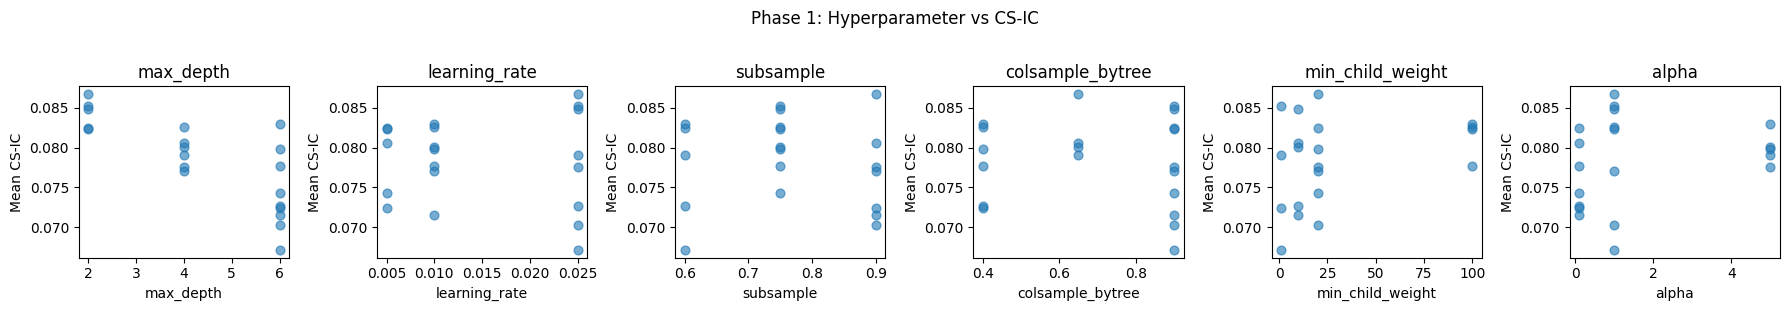

In [276]:
# Scatter plots: CS-IC vs each hyperparameter
hp_names = list(grid_values.keys())
fig, axes = plt.subplots(1, len(hp_names), figsize=(3 * len(hp_names), 3))

for ax, hp in zip(axes, hp_names):
    ax.scatter(p1_df[hp], p1_df["cs_ic"], alpha=0.6, s=40)
    ax.set_xlabel(hp)
    ax.set_ylabel("Mean CS-IC")
    ax.set_title(hp)

fig.suptitle("Phase 1: Hyperparameter vs CS-IC", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\amsac\AppData\Local\Temp\ipykernel_25324\2911029133.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
C:\Users\amsac\AppData\Local\Temp\ipykernel_25324\2911029133.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
C:\Users\amsac\AppData\Local\Temp\ipykernel_25324\2911029133.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
C:\Users\amsac\AppData\Local\Temp\ipykernel_25324

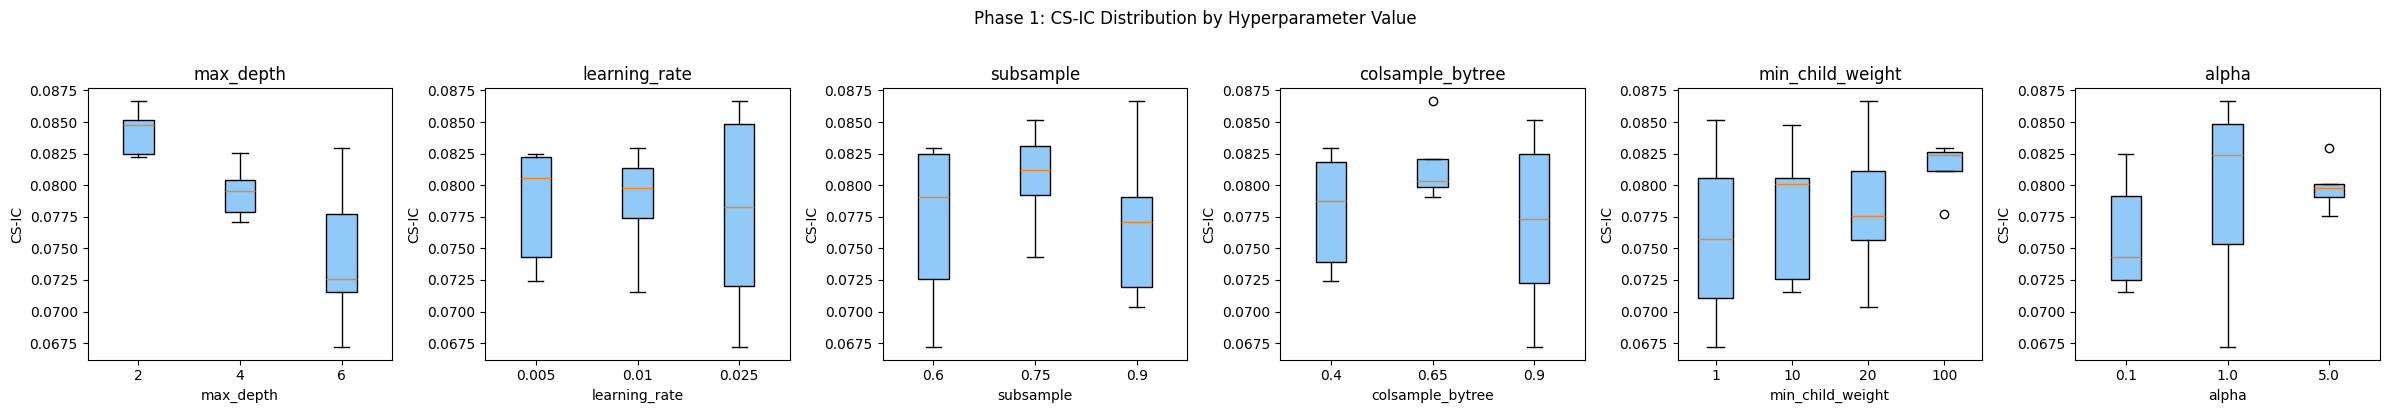

In [277]:
# Box plots: CS-IC distribution by hyperparameter value
fig, axes = plt.subplots(1, len(hp_names), figsize=(4 * len(hp_names), 4))

for ax, hp in zip(axes, hp_names):
    unique_vals = sorted(p1_df[hp].unique())
    data = [p1_df.loc[p1_df[hp] == v, "cs_ic"].values for v in unique_vals]
    bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#90CAF9")
    ax.set_xlabel(hp)
    ax.set_ylabel("CS-IC")
    ax.set_title(hp)

fig.suptitle("Phase 1: CS-IC Distribution by Hyperparameter Value", y=1.02)
plt.tight_layout()
plt.show()

### Narrow the search space

Based on the Phase 1 scatter/box plots above, update the ranges below
to focus on the promising region before running Bayesian optimization.

In [278]:
# ── UPDATE THESE RANGES based on Phase 1 plots ──
# Defaults below are reasonable starting points; refine after inspecting plots.
NARROWED_SPACE = {
    "max_depth": (1, 3),              # (low, high) integer
    "learning_rate": (0.01, 0.03),   # (low, high) log-uniform
    "subsample": (0.75, 0.95),        # (low, high) uniform
    "colsample_bytree": (0.30, 0.65), # (low, high) uniform
    "min_child_weight": (10, 100),      # (low, high) integer

    # Add new params
    "lambda": (0.001, 3.0), 
    "alpha": (0.5, 1.5)
}

print("Narrowed search space for Phase 2:")
for k, v in NARROWED_SPACE.items():
    print(f"  {k}: {v}")

Narrowed search space for Phase 2:
  max_depth: (1, 3)
  learning_rate: (0.01, 0.03)
  subsample: (0.75, 0.95)
  colsample_bytree: (0.3, 0.65)
  min_child_weight: (10, 100)
  lambda: (0.001, 3.0)
  alpha: (0.5, 1.5)


---
## Phase 2: Bayesian Optimization (All Folds)

Optuna TPE sampler explores the narrowed space efficiently.
Each trial is evaluated on ALL folds for robust estimation.

In [ ]:
N_TRIALS = 20


def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", *NARROWED_SPACE["max_depth"]),
        "learning_rate": trial.suggest_float(
            "learning_rate", *NARROWED_SPACE["learning_rate"], log=True
        ),
        "subsample": trial.suggest_float("subsample", *NARROWED_SPACE["subsample"]),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", *NARROWED_SPACE["colsample_bytree"]
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", *NARROWED_SPACE["min_child_weight"]
        ),
        "alpha": trial.suggest_float("alpha", *NARROWED_SPACE["alpha"]),
        "lambda": trial.suggest_float("lambda", *NARROWED_SPACE["lambda"]),
        "nthread": 3,
    }

    results = evaluate_params_on_folds(params, folds, verbose=False)

    mean_mse = float(np.mean(results["fold_mse"])) if results["fold_mse"] else np.nan
    std_mse = float(np.std(results["fold_mse"])) if results["fold_mse"] else np.nan
    spread_sharpe = score_fold_spreads(results["fold_spreads"])
    mean_cs_ic = float(np.mean(results["fold_cs_ic"])) if results["fold_cs_ic"] else np.nan
    std_cs_ic = float(np.std(results["fold_cs_ic"])) if results["fold_cs_ic"] else np.nan
    icir = mean_cs_ic / std_cs_ic if np.isfinite(std_cs_ic) and std_cs_ic > 0 else np.nan

    all_spreads = np.concatenate(results["fold_spreads"]) if results["fold_spreads"] else np.array([])

    trial.set_user_attr("mean_spread", float(np.mean(all_spreads)) if len(all_spreads) > 0 else 0.0)
    trial.set_user_attr("spread_sharpe", float(spread_sharpe))
    trial.set_user_attr(
        "per_fold_spread_sharpe",
        [round(float(sharpe_ratio(s)), 4) for s in results["fold_spreads"]],
    )

    trial.set_user_attr("mean_cs_ic", float(mean_cs_ic))
    trial.set_user_attr("icir", float(icir) if np.isfinite(icir) else np.nan)
    trial.set_user_attr("per_fold_cs_ic", [round(float(ic), 4) for ic in results["fold_cs_ic"]])

    trial.set_user_attr("mean_mse", float(mean_mse))
    trial.set_user_attr("per_fold_mse", [round(float(m), 6) for m in results["fold_mse"]])

    trial.set_user_attr("per_fold_best_iter", [int(n) for n in results["fold_best_iter"]])
    trial.set_user_attr("mean_best_iter", float(np.mean(results["fold_best_iter"])))

    trial.set_user_attr("per_fold_feature_count", [int(n) for n in results["fold_feature_counts"]])

    return mean_cs_ic


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="xgb_tuning_phase2",
)

# Seed with best Phase 1 config
best_p1 = p1_df.iloc[0]
study.enqueue_trial(
    {
        "max_depth": int(best_p1["max_depth"]),
        "learning_rate": float(best_p1["learning_rate"]),
        "subsample": float(best_p1["subsample"]),
        "colsample_bytree": float(best_p1["colsample_bytree"]),
        "min_child_weight": int(best_p1["min_child_weight"]),
        "alpha": float(best_p1["alpha"]),
        "lambda": 1.0,
    }
)

print(
    f"Running {N_TRIALS} Bayesian trials on all {len(folds)} folds ({N_PARALLEL} parallel)..."
)
print("Objective: mean validation CS-IC on raw returns (maximize)")
study.optimize(objective, n_trials=N_TRIALS, n_jobs=N_PARALLEL, show_progress_bar=True)

print(f"\nBest trial #{study.best_trial.number}:")
print(f"  CS-IC:         {study.best_value:.4f}")
print(f"  Mean MSE:      {study.best_trial.user_attrs['mean_mse']:.6f}")
print(f"  Spread Sharpe: {study.best_trial.user_attrs['spread_sharpe']:.3f}")
print(f"  Mean spread:   {study.best_trial.user_attrs['mean_spread']:.4f}")
print(f"  Mean trees:    {study.best_trial.user_attrs['mean_best_iter']:.0f}")
print(f"  Params:        {study.best_params}")


In [280]:
study.trials_dataframe().sort_values("user_attrs_mean_cs_ic", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_colsample_bytree,params_lambda,params_learning_rate,params_max_depth,...,user_attrs_mean_cs_ic,user_attrs_mean_mse,user_attrs_mean_spread,user_attrs_per_fold_best_iter,user_attrs_per_fold_cs_ic,user_attrs_per_fold_mse,user_attrs_per_fold_spread_sharpe,user_attrs_spread_sharpe,system_attrs_fixed_params,state
16,16,0.086208,2026-03-04 22:04:09.428401,2026-03-04 22:16:21.549320,0 days 00:12:12.120919,0.841180,0.531210,2.968744,0.014612,2,...,0.086208,0.310772,0.028266,"[626, 223, 640, 409, 365, 572, 584, 754]","[0.0722, 0.0644, 0.0977, 0.0783, 0.0934, 0.094...","[0.3074, 0.3163, 0.3184, 0.3156, 0.3065, 0.307...","[1.6742, 1.9077, 2.343, 2.4897, 3.2375, 3.7692...",2.713509,NaN,COMPLETE
11,11,0.085894,2026-03-04 21:54:14.749616,2026-03-04 22:03:52.690757,0 days 00:09:37.941141,0.819178,0.432563,2.533679,0.019901,2,...,0.085894,0.310743,0.027960,"[400, 184, 465, 241, 273, 495, 398, 638]","[0.0708, 0.069, 0.0939, 0.0786, 0.0922, 0.0924...","[0.3073, 0.3163, 0.3184, 0.3156, 0.3065, 0.307...","[1.3361, 2.3219, 2.2269, 2.5742, 3.1482, 3.794...",2.672055,NaN,COMPLETE
8,8,0.085626,2026-03-04 21:47:16.366550,2026-03-04 21:55:56.816212,0 days 00:08:40.449662,1.423939,0.501870,2.506043,0.020679,2,...,0.085626,0.310701,0.027423,"[264, 170, 502, 303, 241, 422, 395, 644]","[0.0684, 0.0624, 0.0975, 0.0757, 0.0945, 0.092...","[0.3074, 0.3163, 0.3183, 0.3156, 0.3065, 0.307...","[1.1863, 1.6441, 2.2564, 2.4549, 3.3762, 3.685...",2.573411,NaN,COMPLETE
17,17,0.085499,2026-03-04 22:12:20.384251,2026-03-04 22:22:22.827847,0 days 00:10:02.443596,0.896543,0.427739,2.493294,0.015594,2,...,0.085499,0.310807,0.027404,"[265, 195, 624, 344, 357, 530, 276, 728]","[0.0668, 0.064, 0.0969, 0.0754, 0.0923, 0.0931...","[0.3076, 0.3164, 0.3184, 0.3156, 0.3065, 0.307...","[0.6827, 1.9532, 2.3045, 2.6859, 3.5007, 3.969...",2.653901,NaN,COMPLETE
2,2,0.085323,2026-03-04 21:32:37.714979,2026-03-04 21:43:27.339536,0 days 00:10:49.624557,0.659900,0.307176,1.690773,0.021973,1,...,0.085323,0.311106,0.025991,"[375, 701, 999, 655, 936, 712, 618, 440]","[0.0652, 0.0835, 0.0934, 0.0805, 0.1016, 0.086...","[0.3076, 0.3157, 0.3187, 0.3157, 0.3062, 0.307...","[0.7819, 3.717, 2.5747, 2.4293, 4.0768, 3.9915...",2.882611,NaN,COMPLETE
7,7,0.085316,2026-03-04 21:43:27.431768,2026-03-04 21:54:14.743757,0 days 00:10:47.311989,0.857184,0.478728,1.460038,0.019340,1,...,0.085316,0.311127,0.025857,"[461, 826, 999, 903, 998, 807, 561, 549]","[0.0656, 0.0839, 0.0923, 0.0814, 0.102, 0.0864...","[0.3076, 0.3157, 0.3188, 0.3157, 0.3063, 0.307...","[0.8733, 3.5721, 2.4769, 2.4281, 3.9577, 3.939...",2.796648,NaN,COMPLETE
4,4,0.085301,2026-03-04 21:37:57.285409,2026-03-04 21:48:00.632518,0 days 00:10:03.347109,1.152858,0.392761,1.592900,0.017753,2,...,0.085301,0.310802,0.027838,"[361, 199, 569, 286, 294, 497, 280, 675]","[0.068, 0.0633, 0.0971, 0.0749, 0.0944, 0.0929...","[0.3075, 0.3164, 0.3184, 0.3157, 0.3065, 0.307...","[1.2217, 1.6925, 2.2748, 2.5379, 3.4294, 4.136...",2.672115,NaN,COMPLETE
18,18,0.085287,2026-03-04 22:12:42.151615,2026-03-04 22:22:27.141609,0 days 00:09:44.989994,0.861855,0.422334,2.300616,0.015728,2,...,0.085287,0.310808,0.027293,"[264, 197, 645, 344, 271, 566, 276, 723]","[0.0674, 0.065, 0.0979, 0.0762, 0.0906, 0.0917...","[0.3075, 0.3163, 0.3184, 0.3156, 0.3067, 0.307...","[0.8083, 1.8705, 2.2945, 2.5026, 3.3708, 4.135...",2.653066,NaN,COMPLETE
19,19,0.085271,2026-03-04 22:14:49.142353,2026-03-04 22:23:49.430435,0 days 00:09:00.288082,0.798035,0.425957,2.306182,0.015879,2,...,0.085271,0.310784,0.027883,"[335, 181, 645, 344, 357, 488, 470, 659]","[0.0678, 0.0633, 0.0969, 0.0759, 0.0919, 0.092...","[0.3074, 0.3164, 0.3183, 0.3156, 0.3065, 0.307...","[1.0625, 2.0226, 2.2504, 2.5339, 3.5577, 4.096...",2.740346,NaN,COMPLETE
5,5,0.085229,2026-03-04 21:38:18.887466,2026-03-04 21:51:22.077795,0 days 00:13:03.190329,1.360898,0.340907,0.541121,0.010885,2,...,0.085229,0.310809,0.027821,"[418, 270, 964, 588, 397,

### Phase 2 Analysis

In [281]:
# Trial history
trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df["state"] == "COMPLETE"].sort_values("value", ascending=False)

display_cols = ["number", "value"] + [c for c in trials_df.columns if c.startswith("params_")]
print("Top 10 trials (value = mean CS-IC):")
print(trials_df[display_cols].head(10).to_string(index=False))

Top 10 trials (value = mean CS-IC):
 number    value  params_alpha  params_colsample_bytree  params_lambda  params_learning_rate  params_max_depth  params_min_child_weight  params_subsample
     16 0.086208      0.841180                 0.531210       2.968744              0.014612                 2                       71          0.948032
     11 0.085894      0.819178                 0.432563       2.533679              0.019901                 2                       13          0.797682
      8 0.085626      1.423939                 0.501870       2.506043              0.020679                 2                       55          0.841105
     17 0.085499      0.896543                 0.427739       2.493294              0.015594                 2                       33          0.820583
      2 0.085323      0.659900                 0.307176       1.690773              0.021973                 1                       50          0.788679
      7 0.085316      0.857184          

In [ ]:
# Optimization history: CS-IC over trials
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums = [t.number for t in completed]
trial_vals = [t.value for t in completed]
ax.scatter(trial_nums, trial_vals, alpha=0.5, s=30, color="#2196F3")
running_best = np.maximum.accumulate(trial_vals)
ax.plot(trial_nums, running_best, color="red", linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Mean CS-IC (all folds)")
ax.set_title("Optimization History")
ax.legend()

# Hyperparameter importance
ax = axes[1]
try:
    importance = optuna.importance.get_param_importances(study)
    ax.barh(list(importance.keys()), list(importance.values()), color="#FF9800")
    ax.set_xlabel("Importance")
    ax.set_title("Hyperparameter Importance")
except Exception:
    ax.text(
        0.5,
        0.5,
        "Need more trials for importance",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )

plt.tight_layout()
plt.show()


In [ ]:
# Per-fold metrics for top 5 trials
top_trials = sorted(
    [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
    key=lambda t: t.value,
    reverse=True,
)[:5]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Per-fold validation loss
ax = axes[0]
n_top = len(top_trials)
x = np.arange(len(folds))
width = 0.8 / max(n_top, 1)

for i, trial in enumerate(top_trials):
    fold_mse = trial.user_attrs["per_fold_mse"]
    offset = (i - n_top / 2 + 0.5) * width
    ax.bar(
        x + offset,
        fold_mse,
        width,
        label=f"Trial {trial.number} (CS-IC={trial.value:.4f})",
        alpha=0.8,
    )

ax.set_xticks(x)
ax.set_xticklabels([f"F{i}" for i in range(len(folds))])
ax.set_ylabel("Validation PseudoHuber")
ax.set_title("Top Trials: Per-Fold Validation Loss")
ax.legend(fontsize=8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

# Per-fold validation CS-IC
ax = axes[1]
for i, trial in enumerate(top_trials):
    fold_cs_ic = trial.user_attrs["per_fold_cs_ic"]
    offset = (i - n_top / 2 + 0.5) * width
    ax.bar(
        x + offset,
        fold_cs_ic,
        width,
        label=f"Trial {trial.number} (mean={trial.user_attrs['mean_cs_ic']:.4f})",
        alpha=0.8,
    )

ax.set_xticks(x)
ax.set_xticklabels([f"F{i}" for i in range(len(folds))])
ax.set_ylabel("Validation CS-IC")
ax.set_title("Top Trials: Per-Fold CS-IC")
ax.legend(fontsize=8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()


## Holdout Evaluation with Best Params

In [ ]:
best_params = dict(study.best_params)
best_params


In [174]:
# best_trial = study.trials_dataframe().query("number == 9")

# best_params = {
#     col.replace("params_", ""): best_trial[col].iloc[0] 
#     for col in best_trial 
#     if col.startswith("params_")
# }

# def normalize_types(d):
#     return {
#         k: v.item() if isinstance(v, np.generic) else v
#         for k, v in d.items()
#     }

# best_params = normalize_types(best_params)

# best_params

In [310]:
# len(feature_cols


In [ ]:
def pseudohuber_loss(y_true, y_pred, delta=1.0):
    r = y_true - y_pred
    return float(np.mean(delta ** 2 * (np.sqrt(1 + (r / delta) ** 2) - 1)))


print(f"Evaluating best params on all holdout sets: {best_params}\n")

holdout_metrics = []
holdout_predictions = []
holdout_feature_checks = []

last_model = None
last_holdout_frame = None
last_feature_cols = None

for fold_info in folds:
    train_mask = fold_info["train_mask"]
    val_mask = fold_info["val_mask"]
    holdout_mask = fold_info["holdout_mask"]

    X_tr, y_tr, X_va, y_va, _, fold_features, fold_diag = prepare_fold_data_correct(
        model_df,
        fold_info,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )

    holdout_split_df, holdout_features = compute_cs_features_by_split(
        model_df,
        holdout_mask,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )

    common_features = [c for c in fold_features if c in holdout_features]
    if not common_features:
        print(f"  Fold {fold_info['fold']}: skipped (no common features)")
        continue

    # Re-materialize arrays on common feature set for strict alignment
    train_df, _ = compute_cs_features_by_split(
        model_df,
        train_mask,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )
    val_df, _ = compute_cs_features_by_split(
        model_df,
        val_mask,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )

    X_tr = train_df[common_features].to_numpy(dtype=np.float32)
    y_tr = train_df["ret_eom_t+1_zscore"].to_numpy(dtype=np.float32)
    X_va = val_df[common_features].to_numpy(dtype=np.float32)
    y_va = val_df["ret_eom_t+1_zscore"].to_numpy(dtype=np.float32)

    X_ho = holdout_split_df[common_features].to_numpy(dtype=np.float32)
    y_ho_z = holdout_split_df["ret_eom_t+1_zscore"].to_numpy(dtype=np.float32)

    full_params = {
        "objective": "reg:pseudohubererror",
        "tree_method": "hist",
        "nthread": 3,
        **best_params,
    }

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=common_features)
    dval = xgb.DMatrix(X_va, label=y_va, feature_names=common_features)
    dho = xgb.DMatrix(X_ho, feature_names=common_features)

    model = xgb.train(
        full_params,
        dtrain,
        num_boost_round=1000,
        evals=[(dval, "valid")],
        early_stopping_rounds=30,
        verbose_eval=False,
    )

    preds = model.predict(dho)
    last_model = model
    last_holdout_frame = holdout_split_df.copy()
    last_holdout_frame["pred"] = preds
    last_feature_cols = common_features

    f_phuber = pseudohuber_loss(y_ho_z, preds, delta=1.0)

    ho_df = holdout_split_df[
        ["ticker", "month_end", "ret_eom_t+1", "ret_eom_t+1_zscore"]
    ].copy()
    ho_df["pred"] = preds

    cs_ic = cross_sectional_ic(ho_df, "month_end", "ret_eom_t+1", "pred")
    spreads = compute_monthly_spreads(ho_df, "month_end", "ret_eom_t+1", "pred")
    spread_sharpe = sharpe_ratio(spreads) if len(spreads) >= 3 else 0.0
    mean_spread = float(np.mean(spreads)) if len(spreads) > 0 else np.nan

    # Directional diagnostics
    sign_mask = np.isfinite(ho_df["pred"]) & np.isfinite(ho_df["ret_eom_t+1"])
    if sign_mask.any():
        da = float(
            (
                np.sign(ho_df.loc[sign_mask, "pred"])
                == np.sign(ho_df.loc[sign_mask, "ret_eom_t+1"])
            ).mean()
        )
    else:
        da = np.nan

    monthly_signal = ho_df.groupby("month_end")["pred"].mean()
    monthly_realized = ho_df.groupby("month_end")["ret_eom_t+1"].mean()
    turning = pd.concat(
        [monthly_signal.diff().rename("d_pred"), monthly_realized.diff().rename("d_ret")],
        axis=1,
    ).dropna()
    if not turning.empty:
        tpa = float((np.sign(turning["d_pred"]) == np.sign(turning["d_ret"])).mean())
    else:
        tpa = np.nan

    holdout_metrics.append(
        {
            "fold": fold_info["fold"],
            "holdout_start": fold_info["holdout_start"].strftime("%Y-%m"),
            "holdout_end": fold_info["holdout_end"].strftime("%Y-%m"),
            "fold_phuber": f_phuber,
            "cs_ic": cs_ic,
            "mean_spread": mean_spread,
            "spread_sharpe": spread_sharpe,
            "da": da,
            "tpa": tpa,
            "n_holdout": int(holdout_mask.sum()),
        }
    )

    holdout_feature_checks.append(
        {
            "fold": fold_info["fold"],
            "n_common_features": len(common_features),
            "train_rows": len(train_df),
            "val_rows": len(val_df),
            "holdout_rows": len(holdout_split_df),
            "best_iteration": int(model.best_iteration),
            "best_score": float(model.best_score),
        }
    )

    holdout_predictions.append(ho_df.assign(fold=fold_info["fold"]))

    print(
        f"  Fold {fold_info['fold']}: "
        f"PseudoHuber={f_phuber:.6f}, "
        f"CS-IC={cs_ic:.4f}, "
        f"Spread={mean_spread:.4f}, "
        f"Sharpe={spread_sharpe:.2f}, "
        f"DA={da:.3f}"
    )

holdout_metrics_df = pd.DataFrame(holdout_metrics)
holdout_feature_checks_df = pd.DataFrame(holdout_feature_checks)
holdout_pred_df = (
    pd.concat(holdout_predictions, ignore_index=True) if holdout_predictions else pd.DataFrame()
)

print("\nHoldout summary:")
print(
    f"Mean holdout PseudoHuber: {holdout_metrics_df['fold_phuber'].mean():.6f} "
    f"(std={holdout_metrics_df['fold_phuber'].std():.6f})"
)
print(
    f"Mean holdout CS-IC:       {holdout_metrics_df['cs_ic'].mean():.4f} "
    f"(std={holdout_metrics_df['cs_ic'].std():.4f})"
)
print(f"Mean holdout spread:      {holdout_metrics_df['mean_spread'].mean():.4f}")
print(f"Mean holdout spread SR:   {holdout_metrics_df['spread_sharpe'].mean():.2f}")


In [ ]:
holdout_metrics_df.head()


In [ ]:
print("Feature/fit checks by fold:")
print(holdout_feature_checks_df.to_string(index=False))

holdout_pred_df.head(10)


## Diagnostic Plots

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Huber loss, spread, spread Sharpe
ax = axes[0, 0]
ax.plot(
    holdout_metrics_df["holdout_start"],
    holdout_metrics_df["fold_phuber"],
    "o-",
    color="#2196F3",
)
ax.axhline(
    holdout_metrics_df["fold_phuber"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean={holdout_metrics_df['fold_phuber'].mean():.4f}",
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Huber Loss")
ax.set_title("Holdout Huber Loss Over Time")
ax.legend()
ax.tick_params(axis="x", rotation=45)

ax = axes[0, 1]
ax.bar(
    holdout_metrics_df["holdout_start"],
    holdout_metrics_df["mean_spread"],
    color=["#4CAF50" if s > 0 else "#f44336" for s in holdout_metrics_df["mean_spread"]],
    alpha=0.8,
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Mean Monthly Spread")
ax.set_title("Top-Bottom Decile Spread by Fold")
ax.tick_params(axis="x", rotation=45)

ax = axes[0, 2]
ax.bar(
    holdout_metrics_df["holdout_start"],
    holdout_metrics_df["spread_sharpe"],
    color=["#2196F3" if s > 0 else "#f44336" for s in holdout_metrics_df["spread_sharpe"]],
    alpha=0.8,
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Spread Sharpe")
ax.set_title("Spread Sharpe by Fold")
ax.tick_params(axis="x", rotation=45)

# Row 2: CS-IC, DA, TPA
ax = axes[1, 0]
ax.plot(holdout_metrics_df["holdout_start"], holdout_metrics_df["cs_ic"], "o-", color="#9C27B0")
ax.axhline(
    holdout_metrics_df["cs_ic"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean={holdout_metrics_df['cs_ic'].mean():.4f}",
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Cross-Sectional IC")
ax.set_title("Holdout CS-IC Over Time")
ax.legend()
ax.tick_params(axis="x", rotation=45)

ax = axes[1, 1]
ax.bar(holdout_metrics_df["holdout_start"], holdout_metrics_df["da"], color="#FF9800", alpha=0.8)
ax.axhline(
    holdout_metrics_df["da"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean={holdout_metrics_df['da'].mean():.4f}",
)
ax.axhline(0.5, color="black", linewidth=0.5, linestyle=":")
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Directional Accuracy")
ax.set_title("DA by Fold (0.5 = random)")
ax.legend()
ax.tick_params(axis="x", rotation=45)

ax = axes[1, 2]
ax.bar(holdout_metrics_df["holdout_start"], holdout_metrics_df["tpa"], color="#00BCD4", alpha=0.8)
ax.axhline(
    holdout_metrics_df["tpa"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean={holdout_metrics_df['tpa'].mean():.4f}",
)
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Turning Point Accuracy")
ax.set_title("TPA by Fold")
ax.legend()
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


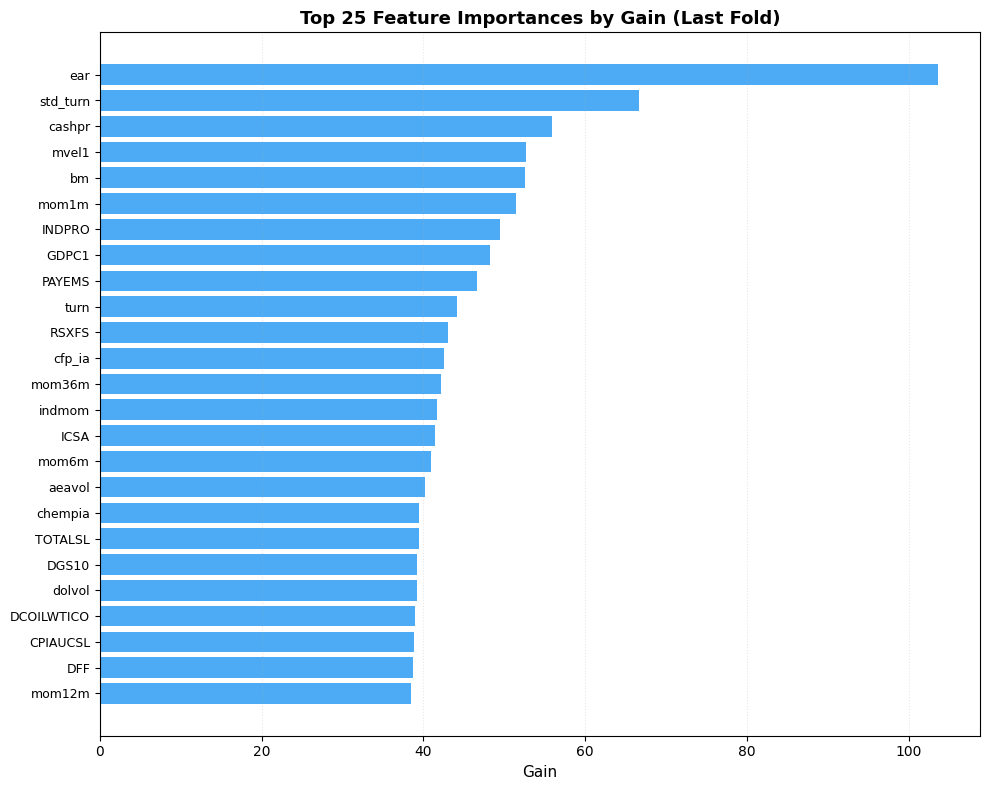

In [290]:
# Feature importance from last fold's model (top 25 by gain)
imp = last_model.get_score(importance_type="gain")
imp_sorted = sorted(imp.items(), key=lambda x: x[1], reverse=True)[:25]
feat_names, feat_gains = zip(*imp_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(feat_names)), feat_gains, color="#2196F3", alpha=0.8)
ax.set_yticks(range(len(feat_names)))
ax.set_yticklabels(feat_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Gain", fontsize=11)
ax.set_title("Top 25 Feature Importances by Gain (Last Fold)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x", linestyle=":")
plt.tight_layout()
plt.show()

In [ ]:
# %pip install shap
import shap

if last_model is None or last_holdout_frame is None or not last_feature_cols:
    raise ValueError("Run the holdout evaluation cell first to build last_model/last_holdout_frame.")

# Use a sample of the last fold's holdout data for SHAP
X_ho_shap = last_holdout_frame[last_feature_cols].copy()

n_sample = min(10000, len(X_ho_shap))
X_sample = X_ho_shap.sample(n=n_sample, random_state=42)

explainer = shap.TreeExplainer(last_model)
shap_values = explainer.shap_values(X_sample)

fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_sample, max_display=25, show=False)
plt.title("SHAP Beeswarm Plot (Last Fold Holdout Sample)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Per-Fold Holdout Backtest

Refit the best model on each fold's train+val data, generate predictions on the holdout period,
and run the backtesting engine with a long-only top 10% strategy.

In [ ]:
from src.backtest import (
    Backtester,
    LongOnlyTopPct,
    LongShortTopBottom,
    compute_metrics,
    print_metrics_comparison,
    create_backtest_report,
)

all_backtest_results = []

# Use tuned average best iteration for train+val refit (no holdout peeking)
default_rounds = int(np.nanmean(study.best_trial.user_attrs.get("per_fold_best_iter", [300])))
num_boost_round = max(default_rounds, 50)

for fold_info in folds:
    train_mask = fold_info["train_mask"]
    val_mask = fold_info["val_mask"]
    holdout_mask = fold_info["holdout_mask"]

    combined_mask = train_mask | val_mask

    fit_df, fit_features = compute_cs_features_by_split(
        model_df,
        combined_mask,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )
    holdout_split_df, holdout_features = compute_cs_features_by_split(
        model_df,
        holdout_mask,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )

    common_features = [c for c in fit_features if c in holdout_features]
    if not common_features:
        print(f"  Fold {fold_info['fold']}: skipped (no common features)")
        continue

    X_fit = fit_df[common_features].to_numpy(dtype=np.float32)
    y_fit = fit_df["ret_eom_t+1_zscore"].to_numpy(dtype=np.float32)
    X_ho = holdout_split_df[common_features].to_numpy(dtype=np.float32)

    full_params = {
        "objective": "reg:pseudohubererror",
        "tree_method": "hist",
        "nthread": 3,
        **best_params,
    }

    dtrain = xgb.DMatrix(X_fit, label=y_fit, feature_names=common_features)
    dho = xgb.DMatrix(X_ho, feature_names=common_features)

    bst = xgb.train(
        full_params,
        dtrain,
        num_boost_round=num_boost_round,
        verbose_eval=False,
    )

    preds = bst.predict(dho)

    ho_data = holdout_split_df[["ticker", "month_end"]].copy()
    ho_data["pred"] = preds
    ho_data = ho_data.merge(
        px_m[["ticker", "month_end", "close"]],
        on=["ticker", "month_end"],
        how="left",
    )

    # Ensure benchmark prices are present even if SPY has no prediction row
    spy_rows = px_m.loc[
        (px_m["ticker"] == "SPY")
        & (px_m["month_end"] >= fold_info["holdout_start"])
        & (px_m["month_end"] <= fold_info["holdout_end"]),
        ["ticker", "month_end", "close"],
    ].copy()
    spy_rows["pred"] = np.nan

    ho_data = pd.concat([ho_data, spy_rows], ignore_index=True)
    ho_data = ho_data.drop_duplicates(["ticker", "month_end"], keep="first")
    ho_data = ho_data.dropna(subset=["close"])

    strategy = LongOnlyTopPct(
        pred_col="pred",
        top_pct=0.10,
        date_col="month_end",
        ticker_col="ticker",
        price_col="close",
        min_price=1.0,
    )

    bt = Backtester(
        data=ho_data,
        strategy=strategy,
        initial_capital=100_000,
        transaction_cost_bps=10,
        short_term_tax_rate=0.0,
        rebalance_frequency="monthly",
        date_col="month_end",
        ticker_col="ticker",
        price_col="close",
        benchmark_ticker="SPY",
    )

    result = bt.run()

    fold_label = (
        f"Fold {fold_info['fold']}: "
        f"{fold_info['holdout_start'].strftime('%Y-%m')} to "
        f"{fold_info['holdout_end'].strftime('%Y-%m')}"
    )

    all_backtest_results.append(
        {
            "fold": fold_info["fold"],
            "label": fold_label,
            "result": result,
        }
    )

    strat_ret = result.metrics.get("annual_return", 0)
    bench_ret = result.benchmark_metrics.get("annual_return", 0)
    strat_sharpe = result.metrics.get("sharpe_ratio", 0)
    print(
        f"  {fold_label} | "
        f"Strat Ann: {strat_ret:.2%}, Bench Ann: {bench_ret:.2%}, "
        f"Sharpe: {strat_sharpe:.2f}"
    )


In [ ]:
# Summary table of backtest metrics across folds
bt_summary = []
for entry in all_backtest_results:
    r = entry["result"]
    bt_summary.append({
        "fold": entry["fold"],
        "period": entry["label"].split(": ")[1],
        "strat_ann_ret": r.metrics.get("annual_return", np.nan),
        "bench_ann_ret": r.benchmark_metrics.get("annual_return", np.nan),
        "excess_ret": r.metrics.get("annual_return", 0) - r.benchmark_metrics.get("annual_return", 0),
        "sharpe": r.metrics.get("sharpe_ratio", np.nan),
        "max_dd": r.metrics.get("max_drawdown", np.nan),
        "win_rate": r.metrics.get("win_rate", np.nan),
        "avg_turnover": r.turnover.mean() if r.turnover is not None else np.nan,
    })

bt_summary_df = pd.DataFrame(bt_summary)
print("Backtest Summary Across Folds:")
print(bt_summary_df.to_string(index=False, float_format="%.4f"))

print(f"\nMean excess return:  {bt_summary_df['excess_ret'].mean():.4f}")
print(f"Mean Sharpe:         {bt_summary_df['sharpe'].mean():.2f}")
print(f"Mean max drawdown:   {bt_summary_df['max_dd'].mean():.2%}")

In [ ]:
# Cumulative returns across all holdout folds (stitched)
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Panel 1: Per-fold cumulative returns (overlaid)
ax = axes[0]
for entry in all_backtest_results:
    r = entry["result"]
    cum_ret = (1 + r.returns).cumprod()
    bench_cum = (1 + r.benchmark_returns).cumprod()
    ax.plot(cum_ret.index, cum_ret.values, linewidth=2, label=f"Fold {entry['fold']} Strategy")
    ax.plot(bench_cum.index, bench_cum.values, linewidth=1, linestyle="--", alpha=0.5,
            color="gray")

ax.set_ylabel("Cumulative Return (multiple)")
ax.set_title("Per-Fold Holdout Cumulative Returns (Strategy vs SPY)", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, ncol=4)
ax.grid(True, alpha=0.3, linestyle=":")
ax.axhline(1.0, color="black", linewidth=0.5)

# Panel 2: Strategy excess return bar chart per fold
ax = axes[1]
colors = ["#4CAF50" if x > 0 else "#f44336" for x in bt_summary_df["excess_ret"]]
ax.bar(bt_summary_df["period"], bt_summary_df["excess_ret"], color=colors, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Annualized Excess Return")
ax.set_title("Strategy Excess Return Over SPY by Fold", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y", linestyle=":")

plt.tight_layout()
plt.show()

## Save Best Params

In [ ]:
# Save best params to JSON (regression model, not XGBRanker)
save_params = {
    "objective": "reg:pseudohubererror",
    "tree_method": "hist",
    **best_params,
}

out_path = f"../data/processed/{run_tag}/best_xgb_reg_params.json"
with open(out_path, "w") as f:
    json.dump(save_params, f, indent=2)

print(f"Saved to {out_path}")
print(f"\nFull params for xgb.train():")
print(json.dumps(save_params, indent=2))
print(f"\nUsage:")
print(f"  import json, xgboost as xgb")
print(f'  params = json.load(open("{out_path}"))')
print(f"  model = xgb.train(params, dtrain, num_boost_round=1000, ...)")